# Seaborn for Exploratory Data Analysis (EDA)

1. Seaborn vs Matplotlib, tidy data, figure-level vs axes-level functions
2. Themes, palettes and context
3. Distributions: `histplot`, `kdeplot`, `ecdfplot`, `displot`
4. Categorical plots: `countplot`, `barplot`, `boxplot`, `violinplot`, `stripplot`/`swarmplot`
5. Relationships: `scatterplot`, `lineplot`, `regplot`/`lmplot`
6. Multivariate: `heatmap`, `pairplot`, `jointplot`, `FacetGrid`
7. Practice - Core tasks
8. Quick Revision

> **Learning approach:** Read the definition → run the example → change the values → observe the output → complete the practice task.

**Dataset used:** `student_tech_profile.csv` - ~600 engineering students with coding habits, academics and placement outcomes.

# 1. Seaborn vs Matplotlib

### Definition

Seaborn is built **on top of** Matplotlib. It adds:
- Statistical plot types (distributions, regression, categorical comparisons) with far less code
- Sensible defaults (colours, spacing, legends)
- Native support for **tidy (long-format) pandas DataFrames** - you pass column names, not raw arrays

**Tidy data** means: each row is one observation, each column is one variable. Seaborn is built around this idea, so most functions look like:

```python
sns.scatterplot(data=df, x="col_a", y="col_b", hue="col_c")
```

### Figure-level vs Axes-level functions - the most important Seaborn concept

| | Axes-level | Figure-level |
|---|---|---|
| Draws onto | one `ax` you already have | its own new Figure |
| Combine with subplots? | Yes - pass `ax=` | No - manages its own figure |
| Examples | `histplot`, `boxplot`, `scatterplot`, `heatmap` | `displot`, `catplot`, `relplot`, `pairplot`, `lmplot`, `jointplot` |
| Can create facets (`col=`, `row=`)? | No | Yes |

Rule of thumb: use **axes-level** functions when you want full control or need to place a plot inside a Matplotlib subplot grid; use **figure-level** functions when you want automatic small-multiples (facets) across categories.

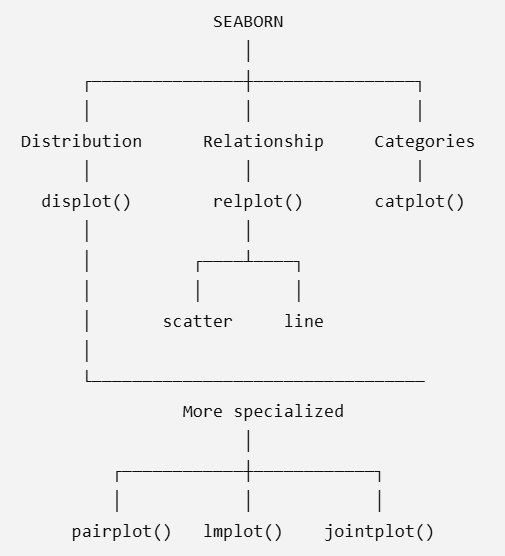

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Seaborn version:", sns.__version__)

Seaborn version: 0.12.2


In [3]:
df = pd.read_csv(r"C:\Users\S Palatheerdham\Downloads\student_tech_profile.csv")
df.head()

,student_id,branch,year,gender,coding_hours_per_week,problems_solved,github_commits,projects_completed,sleep_hours,attendance_pct,cgpa,internship_done,placed,package_lpa
0,S1000,MECH,2,Male,6.4,101,0,3,5.1,100.0,7.29,No,Yes,14.08
1,S1001,EEE,3,Male,2.7,53,15,0,8.0,78.4,7.04,No,Yes,9.34
2,S1002,IT,3,Male,17.5,195,0,6,6.8,65.7,8.01,Yes,Yes,11.11
3,S1003,EEE,3,Male,9.7,180,57,0,5.5,92.5,7.41,No,Yes,3.56
4,S1004,CSE,1,Male,14.5,166,52,2,5.7,63.6,6.70,No,No,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             600 non-null    object 
 1   branch                 600 non-null    object 
 2   year                   600 non-null    int64  
 3   gender                 600 non-null    object 
 4   coding_hours_per_week  600 non-null    float64
 5   problems_solved        600 non-null    int64  
 6   github_commits         600 non-null    int64  
 7   projects_completed     600 non-null    int64  
 8   sleep_hours            600 non-null    float64
 9   attendance_pct         600 non-null    float64
 10  cgpa                   600 non-null    float64
 11  internship_done        600 non-null    object 
 12  placed                 600 non-null    object 
 13  package_lpa            289 non-null    float64
dtypes: float64(5), int64(4), object(5)
memory usage: 65.8+ KB


# 2. Themes, Palettes and Context

### Definition

- `sns.set_theme(style=...)` - overall look: `"whitegrid"`, `"darkgrid"`, `"white"`, `"ticks"`
- `sns.set_context(...)` - scales fonts/lines for `"paper"`, `"notebook"`, `"talk"`, `"poster"`
- Palettes: `"deep"`, `"pastel"`, `"colorblind"` for categories; `"viridis"`, `"rocket"`, `"coolwarm"` for continuous/ordered data
- Every Seaborn function still returns Matplotlib objects, so you can keep using `ax.set_title()`, `plt.savefig()`, etc.

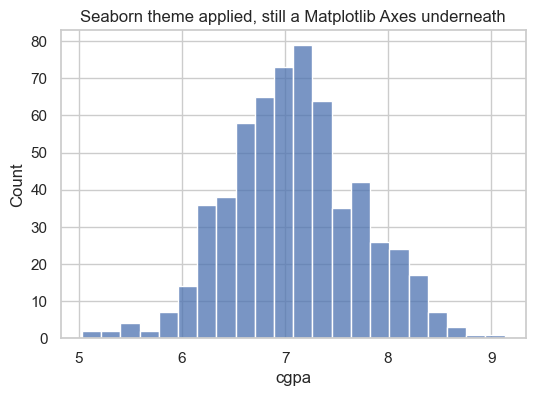

In [10]:
sns.set_theme(style="whitegrid", palette="deep")
sns.set_context("notebook")

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="cgpa", ax=ax)
ax.set_title("Seaborn theme applied, still a Matplotlib Axes underneath")
plt.show()

# Try this: switch style to "darkgrid" and palette to "colorblind", then re-run.

# 3. Distributions

### Definition

| Function | Shows | Notes |
|---|---|---|
| `histplot` | binned counts | add `kde=True` to overlay a smooth density curve |
| `kdeplot` | smoothed density only | good for comparing shapes of multiple groups |
| `ecdfplot` | cumulative distribution | answers "what % of students have X or less?" |
| `displot` | figure-level version of the above | supports `col=`/`row=` facets |

**Reading a distribution:** is it symmetric or skewed? Is there one peak (unimodal) or more than one (bimodal)? Where is most of the data concentrated?

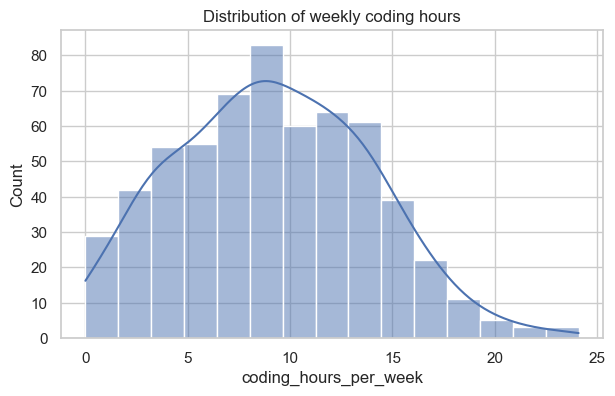

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="coding_hours_per_week", kde=True, ax=ax)
ax.set_title("Distribution of weekly coding hours")
plt.show()

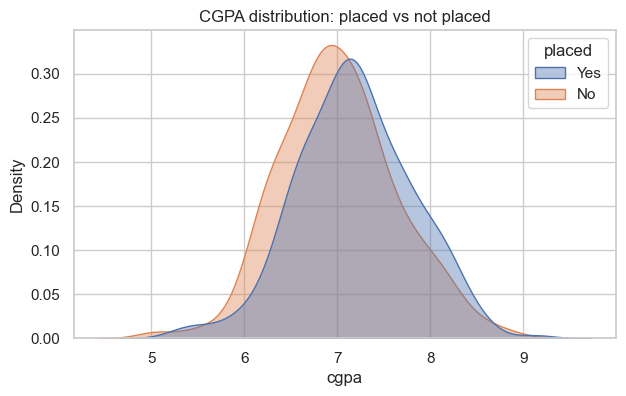

            mean  median
placed                  
No      7.009260    6.97
Yes     7.182907    7.17


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x="cgpa", hue="placed", fill=True, alpha=0.4, ax=ax)
ax.set_title("CGPA distribution: placed vs not placed")
plt.show()
print(df.groupby("placed")["cgpa"].agg(["mean", "median"]))
# Try this: does the "placed" group look shifted to the right (higher CGPA)?

c:\Users\S Palatheerdham\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


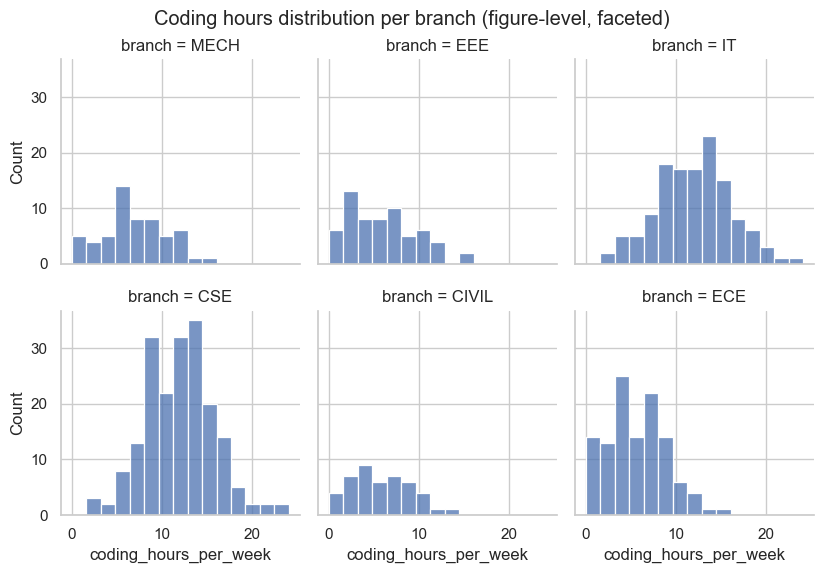

In [16]:
sns.displot(data=df, x="coding_hours_per_week", col="branch", col_wrap=3, height=2.8)
plt.suptitle("Coding hours distribution per branch (figure-level, faceted)", y=1.02)
plt.show()

# displot is figure-level -- notice we did NOT pass ax=, and it created its own grid.

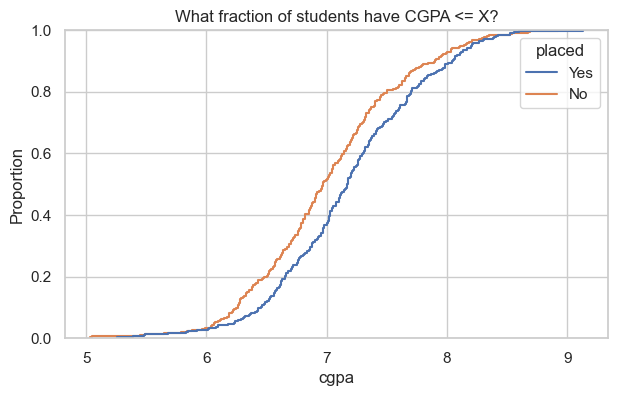

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.ecdfplot(data=df, x="cgpa", hue="placed", ax=ax)
ax.set_title("What fraction of students have CGPA <= X?")
plt.show()

# 4. Categorical Plots

### Definition

| Function | Best for |
|---|---|
| `countplot` | frequency of each category |
| `barplot` | a numeric summary (mean by default) per category, with a confidence interval |
| `boxplot` | median, IQR, outliers per category |
| `violinplot` | full distribution shape per category (like a KDE mirrored) |
| `stripplot` / `swarmplot` | every individual data point per category |

`barplot`'s error bars come from bootstrapped confidence intervals - they tell you how sure we are about the mean, not the spread of raw data (use box/violin for spread).

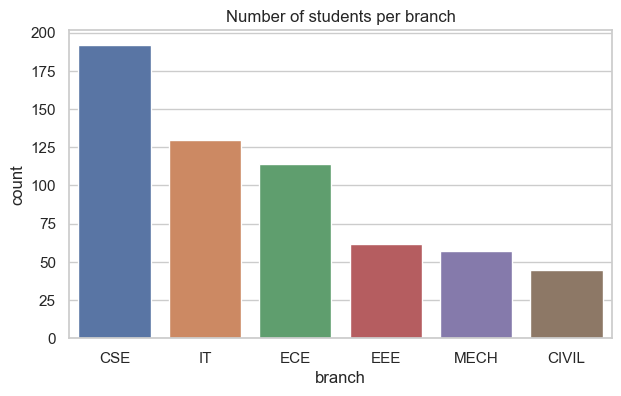

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="branch", order=df["branch"].value_counts().index, ax=ax)
ax.set_title("Number of students per branch")
plt.show()

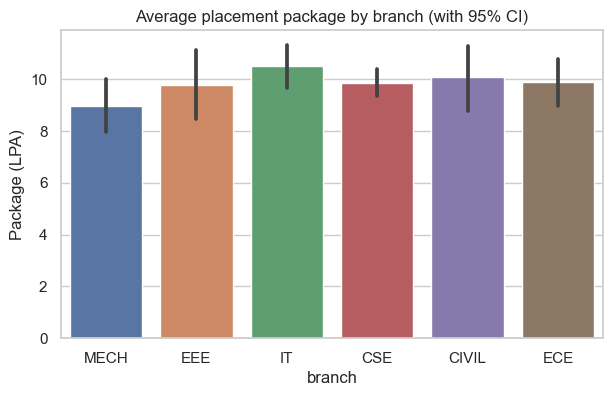

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df, x="branch", y="package_lpa", ax=ax, errorbar="ci")
ax.set_title("Average placement package by branch (with 95% CI)")
ax.set_ylabel("Package (LPA)")
plt.show()

# Try this: change errorbar="ci" to errorbar="sd" and compare the bar heights.

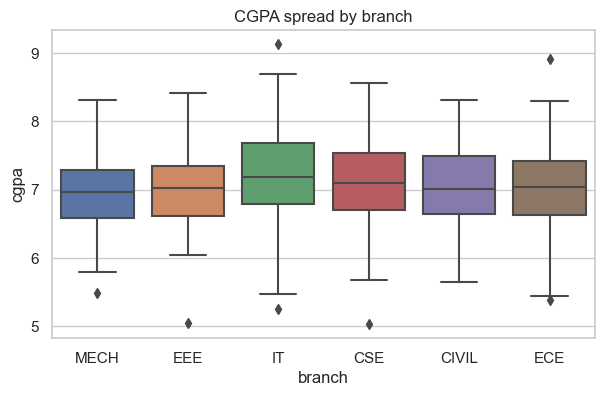

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="branch", y="cgpa", ax=ax)
ax.set_title("CGPA spread by branch")
plt.show()

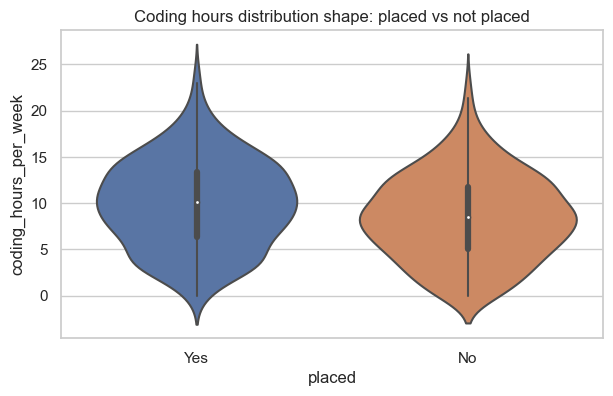

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.violinplot(data=df, x="placed", y="coding_hours_per_week", ax=ax)
ax.set_title("Coding hours distribution shape: placed vs not placed")
plt.show()

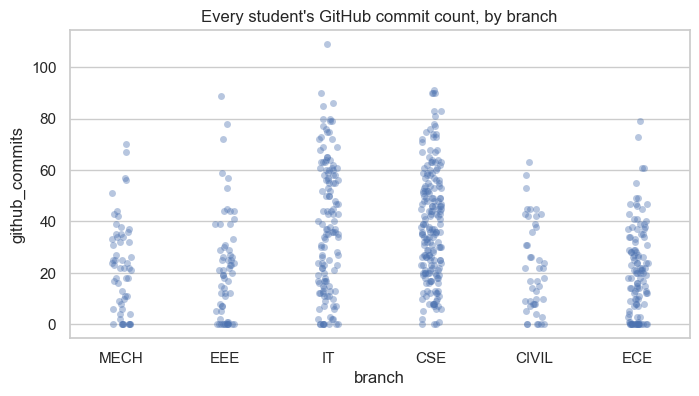

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(data=df, x="branch", y="github_commits", alpha=0.4, ax=ax)
ax.set_title("Every student's GitHub commit count, by branch")
plt.show()

# Try this: swap stripplot for swarmplot (slower, but avoids overlapping points).
# It may take a moment on ~600 points.

# 5. Relationships

### Definition

| Function | Use |
|---|---|
| `scatterplot` | two numeric variables, optionally coloured/sized/styled by a third |
| `lineplot` | trend of y over an ordered x, with an automatic confidence band if there are repeats |
| `regplot` | scatter + a fitted regression line (axes-level) |
| `lmplot` | same idea, figure-level, supports facets (`col=`, `hue=`) |

**Correlation is not causation** - a strong relationship between coding hours and problems solved doesn't prove one *causes* the other; both could be driven by a third factor (interest in the subject, year of study, etc.).

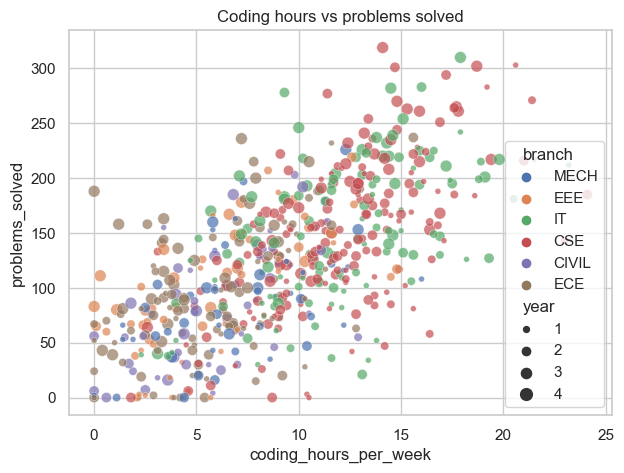

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="coding_hours_per_week", y="problems_solved",
                 hue="branch", size="year", alpha=0.7, ax=ax)
ax.set_title("Coding hours vs problems solved")
plt.show()

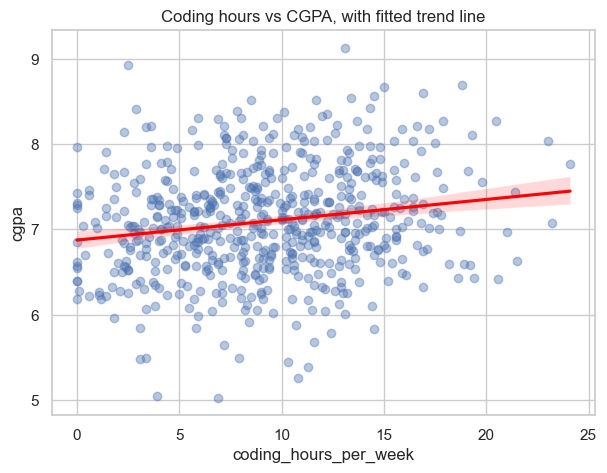

Correlation coefficient: 0.18


In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=df, x="coding_hours_per_week", y="cgpa",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"}, ax=ax)
ax.set_title("Coding hours vs CGPA, with fitted trend line")
plt.show()

corr = df["coding_hours_per_week"].corr(df["cgpa"])
print(f"Correlation coefficient: {corr:.2f}")

c:\Users\S Palatheerdham\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


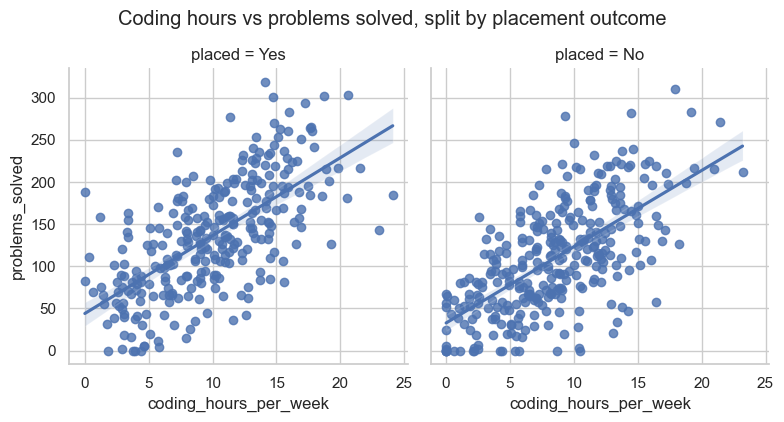

In [25]:
sns.lmplot(data=df, x="coding_hours_per_week", y="problems_solved",
           col="placed", height=4, aspect=1)
plt.suptitle("Coding hours vs problems solved, split by placement outcome", y=1.05)
plt.show()

# lmplot is figure-level: col="placed" automatically makes one panel per group.

# 6. Multivariate Views

### Definition

| Function | Shows |
|---|---|
| `heatmap` | a matrix of values as colour - most common use is a correlation matrix |
| `pairplot` | every numeric column plotted against every other, in one grid |
| `jointplot` | one scatter/hex/KDE plot plus the marginal distributions of both variables |
| `FacetGrid` | manually build a custom grid of small multiples split by one or two categorical columns |

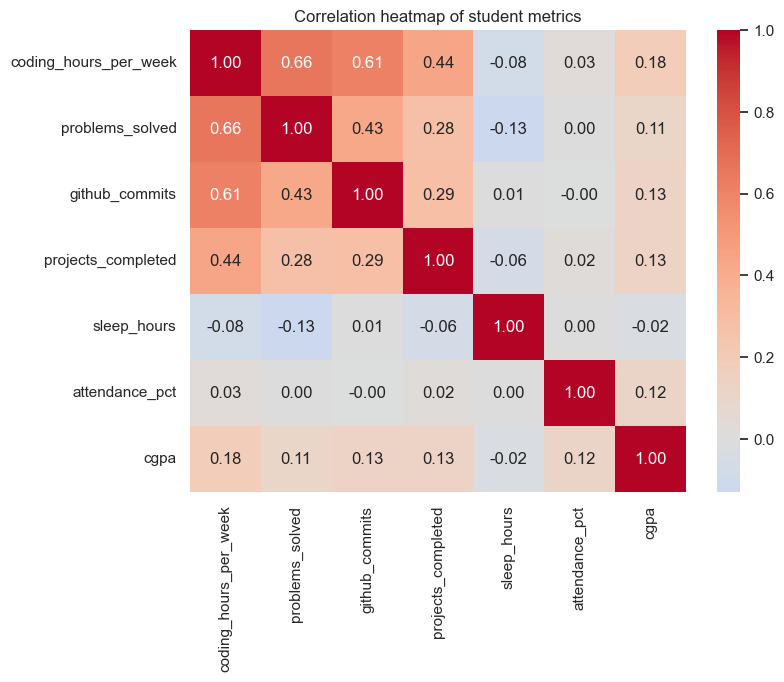

In [26]:
numeric_cols = ["coding_hours_per_week", "problems_solved", "github_commits",
                 "projects_completed", "sleep_hours", "attendance_pct", "cgpa"]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap of student metrics")
plt.show()

# Try this: mask the upper triangle with
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# and pass mask=mask to sns.heatmap(...)

c:\Users\S Palatheerdham\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


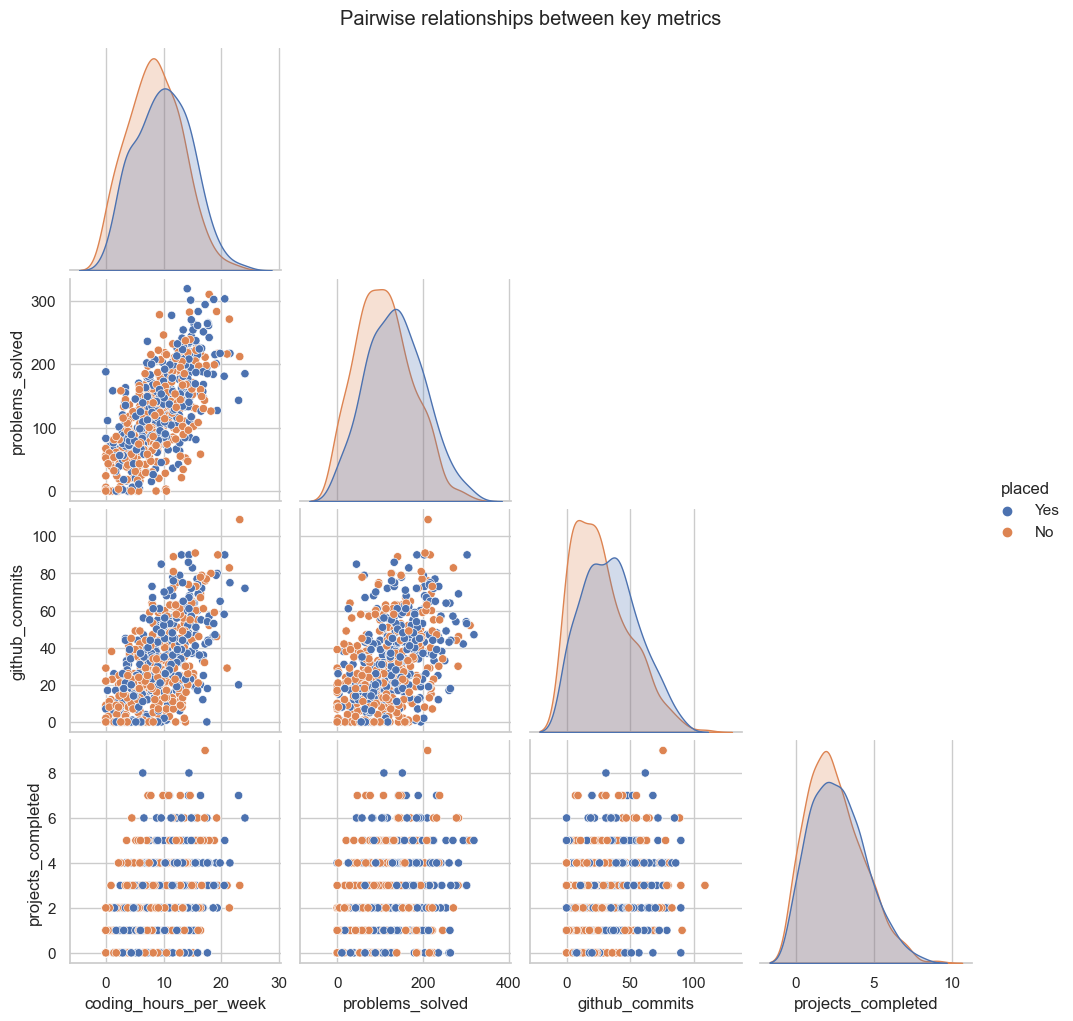

In [27]:
sns.pairplot(df[numeric_cols[:4] + ["placed"]], hue="placed", corner=True)
plt.suptitle("Pairwise relationships between key metrics", y=1.02)
plt.show()

# corner=True skips the redundant upper-triangle plots to keep this readable.

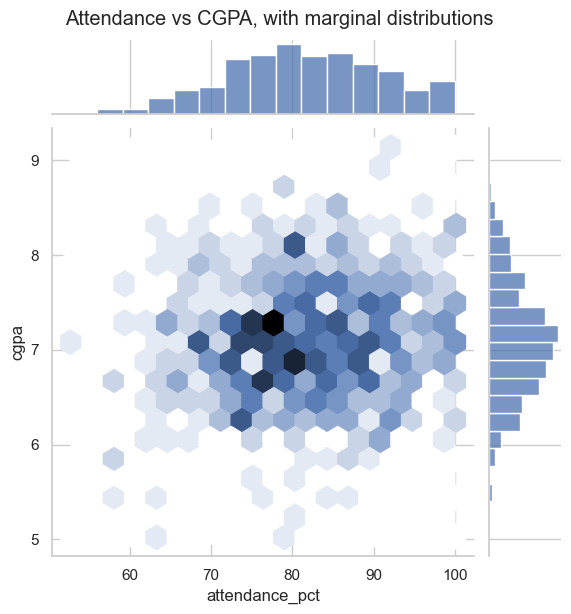

In [29]:
sns.jointplot(data=df, x="attendance_pct", y="cgpa", kind="hex", height=6)
plt.suptitle("Attendance vs CGPA, with marginal distributions", y=1.02)
plt.show()

# Try this: change kind="hex" to kind="kde" or kind="reg" and compare.

c:\Users\S Palatheerdham\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


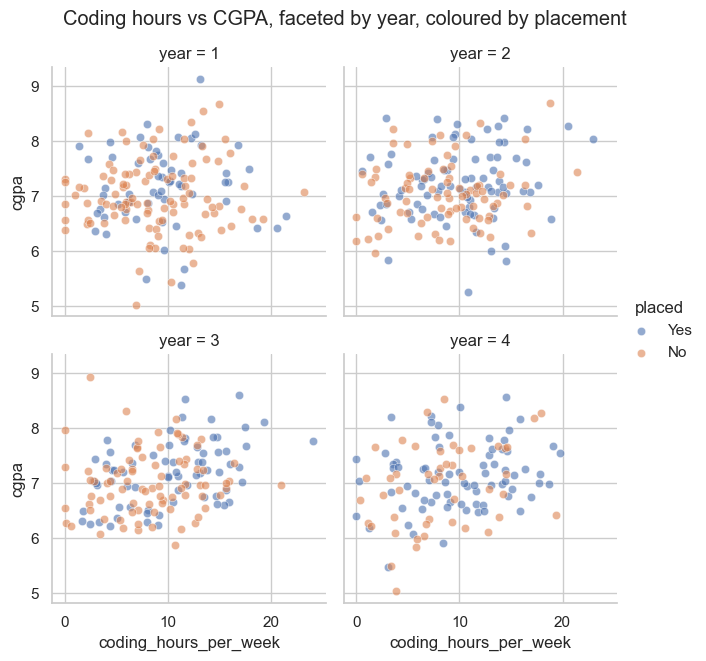

In [30]:
g = sns.FacetGrid(df, col="year", hue="placed", height=3.2, col_wrap=2)
g.map(sns.scatterplot, "coding_hours_per_week", "cgpa", alpha=0.6)
g.add_legend()
g.fig.suptitle("Coding hours vs CGPA, faceted by year, coloured by placement", y=1.03)
plt.show()

# 7. Practice - Apply the Core Concepts

Use `student_tech_profile.csv` for all tasks unless stated otherwise.

### Beginner
1. Plot a `histplot` of `sleep_hours` with `kde=True`.
2. Use `countplot` to show how many students are in each `year`.
3. Use `boxplot` to compare `attendance_pct` across `branch`.

### AI/ML & engineering-focused
4. Use `scatterplot` to plot `github_commits` vs `problems_solved`, coloured by `placed`. What pattern do you see?
5. Build a correlation heatmap using only `sleep_hours`, `coding_hours_per_week`, `cgpa`, and `attendance_pct`. Is sleep positively or negatively related to coding hours?
6. Use `lmplot` or `regplot` to check whether `attendance_pct` predicts `cgpa`. Report the correlation coefficient.
7. Use `pairplot` with `hue="internship_done"` on any 3–4 numeric columns of your choice, and write one sentence on the most interesting pattern you notice.

Write your code (and a one-line comment with your observation) in the cells below.

In [ ]:
# Task 1

In [ ]:
# Task 2

In [ ]:
# Task 3

In [ ]:
# Task 4

In [ ]:
# Task 5

In [ ]:
# Task 6

In [ ]:
# Task 7

# Quick Revision - Seaborn

- **Tidy data:** rows = observations, columns = variables. Seaborn plots take `data=df, x=, y=, hue=`.
- **Axes-level vs Figure-level:** axes-level (`histplot`, `boxplot`, `scatterplot`, `heatmap`) accept `ax=` and fit into subplots. Figure-level (`displot`, `catplot`, `relplot`, `lmplot`, `pairplot`, `jointplot`) manage their own figure and support `col=`/`row=` facets.
- **Distributions:** `histplot` (bins, `kde=True`), `kdeplot` (smooth, good for comparing groups), `ecdfplot` (cumulative %).
- **Categorical:** `countplot` (frequency), `barplot` (mean + CI), `boxplot`/`violinplot` (spread & shape), `stripplot`/`swarmplot` (raw points).
- **Relationships:** `scatterplot` (+ `hue`/`size`/`style`), `regplot`/`lmplot` (fitted trend line). Correlation ≠ causation.
- **Multivariate:** `heatmap` (correlation matrix), `pairplot` (all pairs at once), `jointplot` (scatter + marginals), `FacetGrid` (custom small multiples).
- **Theming:** `sns.set_theme(style=, palette=)`, `sns.set_context(...)` - still plain Matplotlib underneath, so `ax.set_title()` and `plt.savefig()` still work.